In [1]:
import sys 

sys.path.append("../../src")
import kibble_zurek as kz
from common_imports import *
import time_evolved_z_correlators as tz
import warnings
#warnings.filterwarnings("ignore")

In [2]:


#For now we will assume that this will work blindly

def constant_g_evolve(g,state,t):
    u,v,k = state
    u_t,v_t = np.copy(u),np.copy(v)

    for i in range(len(u)):
        ki = k[i]
        ek = sqrt(g*g+2*g*cos(ki)+1)
        ak = g+ cos(ki)
        bk = sin(ki)
        uk,vk = u[i],v[i]/(-1j)


        u_t[i]= uk*cos(2*ek*t)+1j*(ak*uk+bk*vk)*sin(2*ek*t)/ek
        v_t[i]= -1j*vk*cos(2*ek*t)+(bk*uk-ak*vk)*sin(2*ek*t)/ek
    return [u_t,v_t,k]
    

def state_generator(L, tau, tf1, tf2):
    g = 1 - tf1/tau

    times_1 = np.linspace(-10*tau, tf1, 100)
    times_2 = np.linspace(tf1, tf2, 1000)

    states_1 = [kz.state(L, tau, t) for t in times_1]
    psif1 = states_1[-1]

    states_2 = [constant_g_evolve(g, psif1, t - tf1) for t in times_2]

    times = np.concatenate([times_1, times_2])
    states = states_1 + states_2

    return times, states


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


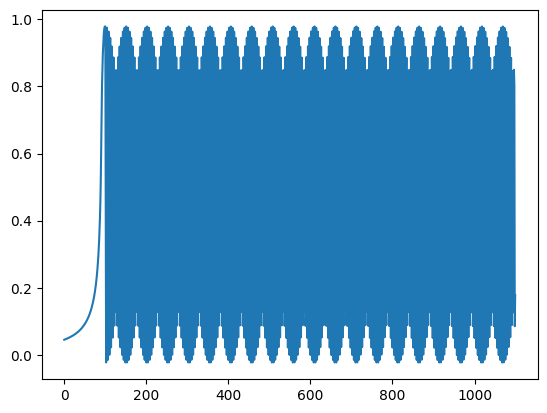

In [3]:
L = 100
tau = 100
times, states = state_generator(L, tau, tau, 5*tau)
xx = array([kz.sigma_general([0,1],s) for s in states])
plot(xx)

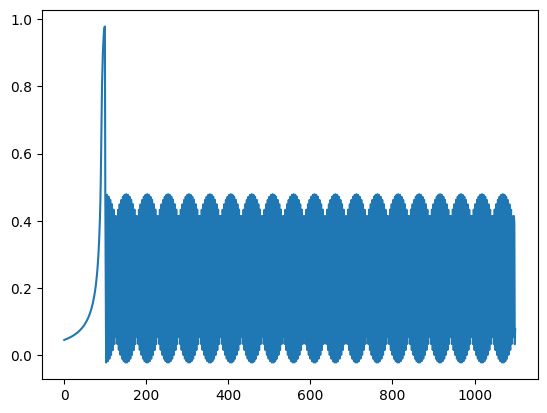

array([-1000.        ,  -988.88888889,  -977.77777778, ...,
         499.1991992 ,   499.5995996 ,   500.        ], shape=(1100,))

(-0.25, 1.0)

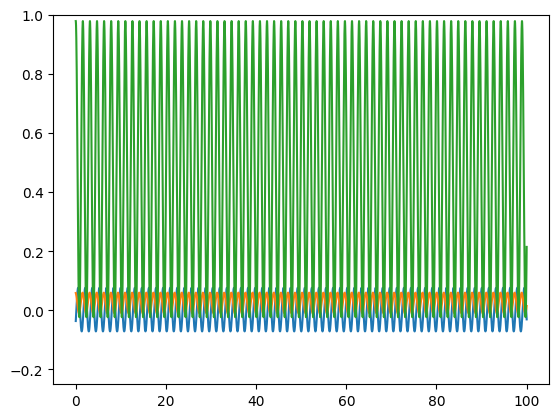

In [303]:
s = kz.state(100,1,100)
times = np.linspace(0,100,10000)
states = [constant_g_evolve(0,s,ti) for ti in times]
xx = [kz.sigma_general([0,1],s) for s in states]

plot(times,xx)
ylim(-.25,1)

s = kz.state(100,10,100)
times = np.linspace(0,100,10000)
states = [constant_g_evolve(0,s,ti) for ti in times]
xx = [kz.sigma_general([0,1],s) for s in states]

plot(times,xx)
ylim(-.25,1)

s = kz.state(100,100,100)
times = np.linspace(0,100,10000)
states = [constant_g_evolve(0,s,ti) for ti in times]
xx = [kz.sigma_general([0,1],s) for s in states]

plot(times,xx)
ylim(-.25,1)

In [4]:
import kblock_ising_model as kb
k = kb.k_vals(100)
U = kb.U(k,0)
U[1]

array([-0.01570732, -0.04710645, -0.0784591 , -0.10973431, -0.14090123,
       -0.1719291 , -0.2027873 , -0.23344536, -0.26387305, -0.29404033,
       -0.32391742, -0.35347484, -0.38268343, -0.41151436, -0.43993917,
       -0.46792981, -0.49545867, -0.52249856, -0.54902282, -0.57500525,
       -0.60042023, -0.62524266, -0.64944805, -0.67301251, -0.6959128 ,
       -0.7181263 , -0.73963109, -0.76040597, -0.78043041, -0.79968466,
       -0.81814972, -0.83580736, -0.85264016, -0.86863151, -0.88376563,
       -0.89802758, -0.91140328, -0.92387953, -0.93544403, -0.94608536,
       -0.95579301, -0.96455742, -0.97236992, -0.97922281, -0.98510933,
       -0.99002366, -0.99396096, -0.99691733, -0.99888987, -0.99987663,
        0.99987663,  0.99888987,  0.99691733,  0.99396096,  0.99002366,
        0.98510933,  0.97922281,  0.97236992,  0.96455742,  0.95579301,
        0.94608536,  0.93544403,  0.92387953,  0.91140328,  0.89802758,
        0.88376563,  0.86863151,  0.85264016,  0.83580736,  0.81

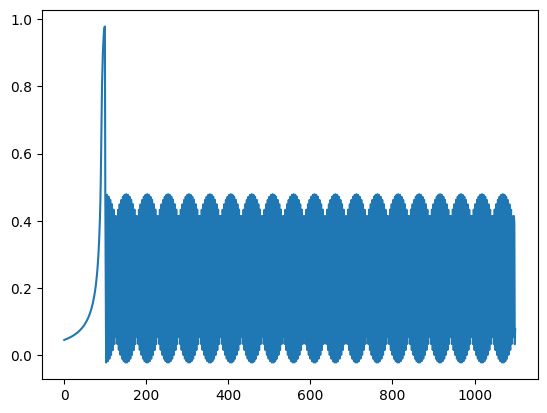

In [453]:

#most correct

#Possible issues are g and J signs

def constant_g_evolve(g, state, t):
    u, v, k = state
    u_t = np.empty_like(u, dtype=complex)
    v_t = np.empty_like(v, dtype=complex)

    for i, qi in enumerate(k):
        a = (g+cos(qi))
        b = -sin(qi)
        Eq = 2*sqrt(a*a+b*b)

        C = cos(Eq*t)
        S = sin(Eq*t)

        u0, v0 = u[i], v[i]

        u_t[i] = (C+2j*a*S/Eq)*u0-2*b*S*v0/Eq
        v_t[i] = u0*2*S*b/Eq+(C-2j*a*S/Eq)*v0

    return (u_t, v_t, k)

def constant_g_evolve(state,t,tf,tau):
    u,v,k = state
    u_t = np.empty_like(u, dtype=complex)
    v_t = np.empty_like(v, dtype=complex)

    for i, qi in enumerate(k):
        alpha_q = 1 + cos(qi)
        beta_q = sin(qi)
        A = (tf/tau-alpha_q)
        B = -beta_q
        Eq = 2*sqrt(A*A+B*B)

        C = cos(Eq*t)
        S = sin(Eq*t)
        u0, v0 = u[i], v[i]
        u_t[i]= u0*(C-2j*A*S/Eq)-v0*2*B*S/Eq
        v_t[i]= u0*(2*B*S/Eq)+   v0*(C+2j*A*S/Eq)

    return (u_t,v_t,k)


(0.9999187408929501+0j)


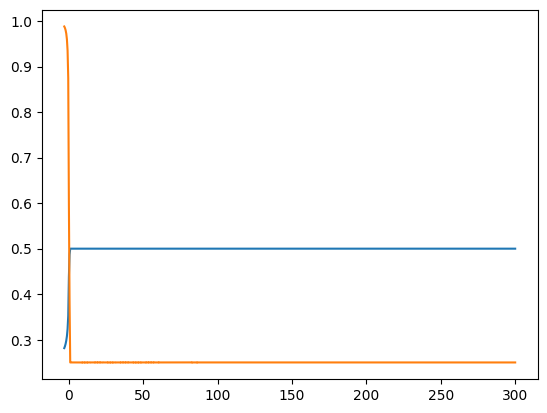

In [506]:
tau = 1000
tf = tau
gf = 1-tf/tau
tf2 = 300*tau
times_1 = np.linspace(-3*tau,tf,10)
times_2 = np.linspace(tf,tf2,3000)
states_1 = [kz.state(100,tau,ti) for ti in times_1]
print(kz.sigma_general([0,1],states_1[-1]))
states_2 = [constant_g_evolve(states_1[-1],t-tf,tf,tau) for t in times_2[1:]]
states = states_1+states_2
times = np.concatenate([times_1, times_2[1:]])
xx = [kz.P_n(2,s) for s in states]
#plt.vlines(tf,0,1)
plot(times/tau,xx)
xx = [tz.P_n(2,s) for s in states]
#plt.vlines(tf,0,1)
plot(times/tau,xx)
#ylim(-.2,1.1)

In [438]:
sL = states_1[-1]
sR = constant_g_evolve(sL, 0.0, tf, tau)
np.max(np.abs(sL[0]-sR[0])), np.max(np.abs(sL[1]-sR[1]))


(np.float64(0.0), np.float64(0.0))